<a href="https://colab.research.google.com/github/fphsFischmeister/ILAE_NeuroimagingSchool/blob/master/notebooks/04_phrases_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Google Colab"/>  </a>

# Welcome to the interactive ILAE workshop on task-based activation detection.

Author: Florian Ph.S Fischmeister, Marc Berger, Radeshyam Stepponat

---
- Part 1: Preprocessing fMRI data with fMRIPrep
- Part 2: First Level of a simple motor task
- Part 3: A Home-Town-Walking language paradigm
- Part 4: Phrases, a language paradigm
- Part 5: All language tasks
- Part 6: Functional Connectivity

In [12]:
# get some data for presentation
!rm -rf ILAE_NeuroimagingSchool
!git clone https://github.com/fphsFischmeister/ILAE_NeuroimagingSchool.git

# get some functional motor data
!wget https://dinlab.roentgen.meduniwien.ac.at/ILAE_NeuroimagingSchool/dataset/sub-ILAEDemo001_ses-01_task-Rest_run-01_space-MNI_desc-denoised_bold.nii.gz -P ILAE_NeuroimagingSchool/dataset/func/


Cloning into 'ILAE_NeuroimagingSchool'...
remote: Enumerating objects: 201, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 201 (delta 72), reused 95 (delta 33), pack-reused 66 (from 2)
Receiving objects: 100% (201/201), 139.06 MiB | 25.47 MiB/s, done.
Resolving deltas: 100% (90/90), done.
--2026-05-05 17:51:13--  https://dinlab.roentgen.meduniwien.ac.at/ILAE_NeuroimagingSchool/dataset/sub-ILAEDemo001_ses-01_task-Rest_run-01_space-MNI_desc-denoised_bold.nii.gz
Resolving dinlab.roentgen.meduniwien.ac.at (dinlab.roentgen.meduniwien.ac.at)... 149.148.226.8
Connecting to dinlab.roentgen.meduniwien.ac.at (dinlab.roentgen.meduniwien.ac.at)|149.148.226.8|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 909146296 (867M) [application/octet-stream]
Saving to: ‘ILAE_NeuroimagingSchool/dataset/func/sub-ILAEDemo001_ses-01_task-Rest_run-01_space-MNI_desc-denoised_bold.nii.gz’

sub-ILAEDemo001_ses 100%[=====

In [2]:
# install modules
%pip install nilearn
%pip install ipyniivue
%pip install ipywidgets
%pip install matplotlib

import numpy as np
import pandas as pd
import nibabel as nib
import nilearn
from pathlib import Path

/home/fischmei/ILAE_NeuroimagingSchool/.venv/bin/python3: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/fischmei/ILAE_NeuroimagingSchool/.venv/bin/python3: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/fischmei/ILAE_NeuroimagingSchool/.venv/bin/python3: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/fischmei/ILAE_NeuroimagingSchool/.venv/bin/python3: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# some basic analysis definitions for later use
task_label = "Phrases"
task_tr= 1 # in seconds
smoothing_fwhm = 8 # in mm, for smoothing the data

nifti_filename = "./ILAE_NeuroimagingSchool/dataset/func/sub-ILAEDemo001_ses-01_task-Rest_run-01_space-MNI_desc-denoised_bold.nii.gz"
confounds_filename = "./ILAE_NeuroimagingSchool/dataset/func/sub-ILAEDemo001_ses-01_task-Rest_run-01_desc-confounds_timeseries.tsv"

!mkdir -p "./ILAE_NeuroimagingSchool/outputs/"
output_dir = "./ILAE_NeuroimagingSchool/outputs/"
# Read the NIfTI header to get the frame time
frame_time = np.arange(nib.load(nifti_filename).shape[3])*task_tr


# Part 6: Connectome of a simple language task

In this notebook, we perform a first-level task-based fMRI analysis of a simple language paradigm using Nilearn. This analysis builds on the preprocessing notebook: we assume that the raw MRI data have already been preprocessed with fMRIPrep and that the relevant outputs are available in BIDS-Derivatives format. The main inputs are the preprocessed BOLD image, the task events file, the brain mask, and selected confound regressors from fMRIPrep. 

The goal is to estimate, for one participant and one functional run, which brain regions show BOLD signal changes associated with the language task. To do this, we fit a first-level general linear model, or GLM, which is applied voxel by voxel. The model compares the measured BOLD time series with a predicted BOLD response derived from the experimental paradigm. Events such as phrases in this case are described in an *events.tsv* file, transformed into predicted BOLD responses by convolution with a haemodynamic response function, or HRF, and combined into a design matrix. The statistical analysis then tests whether a contrast of design-matrix columns explains a significant proportion of the fMRI signal at each brain location.



## Brain parcellation
As a first step, let’s define the regions we want to extract the signal from. For this we can use nilearn’s great “dataset” function. How about the Harvard-Oxford Atlas? At first, we download the atlas and corresponding data via the fetch_atlas_harvard_oxford. Please note that we will use the default version but one can also specify the probabilities and resolution.

In [3]:
from nilearn import datasets
atlas_ho = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')

[fetch_atlas_harvard_oxford] Dataset created in /home/fischmei/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz ...
Downloaded 950272 of 25716861 bytes (3.7%%,   27.2s remaining)
Downloaded 7897088 of 25716861 bytes (30.7%%,    4.8s remaining)
Downloaded 16039936 of 25716861 bytes (62.4%%,    1.9s remaining)
Downloaded 23289856 of 25716861 bytes (90.6%%,    0.4s remaining)
[fetch_atlas_harvard_oxford]  ...done. (5 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from /home/fischmei/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...
[fetch_atlas_harvard_oxford] .. done.



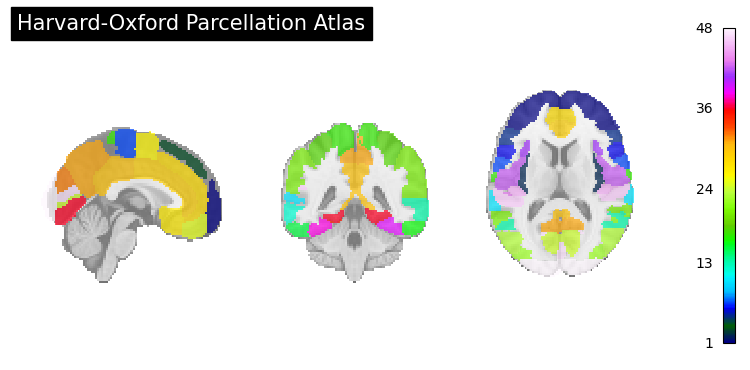

In [6]:
from nilearn import plotting
# Location of HarvardOxford parcellation atlas
atlas_file = atlas_ho.maps

# Visualize parcellation atlas
plotting.plot_roi(atlas_file, draw_cross=False, annotate=False, title="Harvard-Oxford Parcellation Atlas");

In [7]:
# Load labels for each atlas region
labels = atlas_ho.labels[1:]
labels[:10]

['Frontal Pole',
 'Insular Cortex',
 'Superior Frontal Gyrus',
 'Middle Frontal Gyrus',
 'Inferior Frontal Gyrus, pars triangularis',
 'Inferior Frontal Gyrus, pars opercularis',
 'Precentral Gyrus',
 'Temporal Pole',
 'Superior Temporal Gyrus, anterior division',
 'Superior Temporal Gyrus, posterior division']

## Extract timeseries to construct a functional connectome

In [11]:
from nilearn.input_data import NiftiLabelsMasker
masker = NiftiLabelsMasker(labels_img=atlas_file, standardize=True, verbose=1,
                           memory="nilearn_cache", memory_level=2)
time_series = masker.fit_transform(nifti_filename, confounds=confounds_filename)

[NiftiLabelsMasker.wrapped] Loading regions from <nibabel.nifti1.Nifti1Image object at 0x72178054a330>
[NiftiLabelsMasker.wrapped] Resampling regions
________________________________________________________________________________
[Memory] Calling nilearn.image.resampling.resample_img...
resample_img(<nibabel.nifti1.Nifti1Image object at 0x72177e308590>, interpolation='nearest', target_shape=(64, 81, 61), target_affine=array([[  2.281   ,   0.      ,   0.      , -72.809906],
       [  0.      ,   2.281   ,   0.      , -84.019417],
       [  0.      ,   0.      ,   2.5     , -79.733879],
       [  0.      ,   0.      ,   0.      ,   1.      ]]))
_____________________________________________________resample_img - 0.0s, 0.0min


/tmp/ipykernel_18386/3575562045.py:4: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.uint8(48)}. Label image only contains 48 labels (including background).
  time_series = masker.fit_transform(nifti_filename, confounds=confounds_filename)


[NiftiLabelsMasker.wrapped] Finished fit
________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker.filter_and_extract...
filter_and_extract('./ILAE_NeuroimagingSchool/dataset/func/sub-ILAEDemo001_ses-01_task-Phrases_run-01_space-T1w_desc-preproc_bold.nii.gz', 
{ 'background_label': 0,
  'clean_args': None,
  'clean_kwargs': {},
  'cmap': 'CMRmap_r',
  'detrend': False,
  'dtype': None,
  'high_pass': None,
  'high_variance_confounds': False,
  'keep_masked_labels': False,
  'labels': None,
  'labels_img': <nibabel.nifti1.Nifti1Image object at 0x72178054a330>,
  'low_pass': None,
  'lut': None,
  'mask_img': None,
  'reports': True,
  'smoothing_fwhm': None,
  'standardize': True,
  'standardize_confounds': True,
  'strategy': 'mean',
  't_r': None,
  'target_affine': None,
  'target_shape': None}, confounds=[ './ILAE_NeuroimagingSchool/dataset/func/sub-ILAEDemo001_ses-01_task-Phrases_run-01_desc-confounds_timeseries.ts

/tmp/ipykernel_18386/3575562045.py:4: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(nifti_filename, confounds=confounds_filename)


____________________________________nifti_labels_masker_extractor - 2.1s, 0.0min
[NiftiLabelsMasker.wrapped] Cleaning extracted signals
________________________________________________________________________________
[Memory] Calling nilearn.signal.clean...
clean(array([[1106.3429, ...,  522.6582],
       ...,
       [1108.7085, ...,  536.2397]], shape=(300, 47), dtype=float32), detrend=False, standardize=True, standardize_confounds=True, t_r=None, low_pass=None, high_pass=None, confounds=[ './ILAE_NeuroimagingSchool/dataset/func/sub-ILAEDemo001_ses-01_task-Phrases_run-01_desc-confounds_timeseries.tsv'], sample_mask=None, runs=None)


/tmp/ipykernel_18386/3575562045.py:4: DeprecationWarning: From release 0.14.0, confounds will be standardized using the sample std instead of the population std.
  time_series = masker.fit_transform(nifti_filename, confounds=confounds_filename)


ValueError: array must not contain infs or NaNs

## The language task
In a simple home-town walking task, participants are asked to walk in language during task blocks and remain still during rest blocks.

The design is again in an interval of 30 sec. REST, 30 sec. TASK, ... for 5 min.

In [ ]:
# load the event file and show content

task_events_data = pd.read_csv(event_filename, sep="\t")
if 'onset' not in task_events_data.columns:
    raise KeyError("Missing 'onset' column in events file")
if 'trial_type' not in task_events_data.columns:
    raise KeyError("Missing 'trial_type' column in events file")
if 'duration' not in task_events_data.columns:
    raise KeyError("Missing 'duration' column in events file")
task_events_data['onset'] = task_events_data['onset'].astype(float)
design_events = pd.DataFrame({
    'trial_type': task_events_data['trial_type'],
    'onset': task_events_data['onset'],
    'duration': task_events_data['duration']
})
print(design_events.head())

Optionally, the events can be visualized ... not very interesting though

In [ ]:
from nilearn.plotting import plot_event, show

fig = plot_event(design_events)
fig.suptitle("language Task Events")
show()

## Building the design matrix

The design matrix describes the model that will be fitted to the BOLD signal. Each row corresponds to one fMRI volume, and each column corresponds to one model regressor. Task regressors model the expected BOLD response to each condition. Additional columns may model slow scanner drift, head motion, non-steady-state volumes, or other nuisance effects.

The design matrix is the central object of the first-level GLM. It specifies what signal changes we expect to observe during the language task and which nuisance effects we want to account for. Before fitting or interpreting the model, we thus inspect the design matrix carefully. The task regressor should follow the timing of the task blocks or events, while drift and confound regressors should capture slow signal fluctuations or motion-related effects. If the design matrix does not match the experimental paradigm, the resulting activation map will not be meaningful.

Here we will use *FirstLevelModel* to generate the design matrix from the events object, fit the model to the fMRI image, and then inspect the resulting design matrix. 

In [ ]:
# generate design matrix
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
import matplotlib.pyplot as plt


design_matrix = make_first_level_design_matrix(
    frame_times=frame_time,
    events=design_events,
    hrf_model='spm',
    drift_model=None)

# Plot the design matrix
plot_design_matrix(design_matrix)
plt.title(f"Design Matrix - {task_label}")

In [ ]:
# plotting the expected response for the motor condition
import matplotlib.pyplot as plt

plt.plot(design_matrix)
plt.xlabel("scan")
plt.title("Expected Motor Response")


In [ ]:
# plot correlation between regressors
from nilearn.plotting import plot_design_matrix_correlation
plot_design_matrix_correlation(design_matrix)
plt.title(f"Design Matrix Correlation for task - {task_label}")

## Fitting the GLM model
The GLM is fitted independently at each voxel. For every voxel, the model estimates how strongly the observed BOLD time series is associated with the motor-task regressor, while accounting for other regressors in the design matrix. The resulting model parameters are not yet a final activation map. We still need to define a contrast, see below, that expresses the specific experimental question.

A typical model specifies the repetition time, the HRF model, a drift model, a high-pass filter, a brain mask, and optionally smoothing and confound regressors.

In [ ]:
# using ar1 autocorrelation (FSL prewhitening), drift model
fmri_glm = FirstLevelModel(subject_label='sub-ILAEDemo001', mask_img=mask_filename,
                            t_r=task_tr, smoothing_fwhm=smoothing_fwhm,
                            standardize=False, noise_model='ar1', drift_model=None, high_pass=None
                            )
# Run GLM model using set paths and calculate design matrix
fmri_glm = fmri_glm.fit(nifti_filename, design_matrices=design_matrix)

## Calculation of Contrast and z-Map

The contrast vector tells the model which experimental effect we want to test. In this case, we assign a positive weight to the motor condition. This tests whether the BOLD signal is higher during motor-task periods than during the implicit baseline or rest condition. The contrast matrix should be inspected to make sure that the intended condition, and only the intended condition, has been selected.

The calculated z-map shows the statistical evidence for the motor contrast at each voxel. Positive z-values indicate voxels where the BOLD signal is higher during the motor condition than during baseline. Negative z-values would indicate the opposite effect. For visualization, we threshold the z-map so that only stronger effects are displayed. 

In [ ]:
# Compute z-score of specified contrast and save to file
contrast_vector = [[ 1 ]] # Phrases > Baseline
zscore_filename = Path(
    output_dir) / f"T-test_task-{task_label}_z-score.nii.gz"

zscore_est = fmri_glm.compute_contrast(
    contrast_vector, output_type="z_score")
zscore_est.to_filename(zscore_filename)


## Thresholding and Visualization
Thresholding makes the activation map easier to visualize, but the threshold must be interpreted carefully. A liberal threshold may show many voxels, including false positives. A conservative threshold may remove true but weaker activation. For this teaching example, we display a thresholded z-map to illustrate the expected motor network. In a formal study, the thresholding strategy should be defined a priori and reported explicitly.

The thresholded z-map shows task-related activation during the motor condition. The strongest activation is expected near the precentral gyrus, corresponding to primary motor cortex. For a right-hand movement task, the main cortical activation should usually be left-sided; for a left-hand movement task, it should usually be right-sided. Additional activation may be visible in supplementary motor area, premotor cortex, sensory cortex, or cerebellum. The exact pattern depends on task performance, movement side, image quality, susceptibility artifacts, motion, and statistical threshold.

In [ ]:
# print contrast
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display
import ipywidgets as widgets
from ipyniivue import NiiVue, ShowRender, SliceType

# Create NiiVue instance with specific settings
nv = NiiVue(
    loading_text="waiting",
    back_color=(1, 1, 1, 1),
    show_3d_crosshair=True,
    is_colorbar=True,
    multiplanar_show_render=ShowRender.ALWAYS,
)

# Set initial configuration
nv.set_radiological_convention(False)
nv.set_slice_type(SliceType.MULTIPLANAR)
nv.set_slice_mm(False)
nv.set_interpolation(True)

# Load 4D volume with paired HEAD and BRIK files
nv.load_volumes(
    [
        {
            "path": "./ILAE_NeuroimagingSchool/dataset/anat/sub-ILAEDemo001_ses-01_run-01_desc-preproc-noskull_T1w.nii.gz",
        },
        {
            "path": "./ILAE_NeuroimagingSchool/outputs/T-test_task-Phrases_z-score.nii.gz",
            "colormap": "warm",
            "colormap_negative": "winter",
            "cal_min": 3,
            "cal_max": 6,
            "cal_min_neg": -6,
            "cal_max_neg": -3,
        },
    ]
)


# Hide colorbar for anatomical scan
nv.volumes[0].colorbar_visible = False

# Set initial overlay outline
nv.overlay_outline_width = 0.25

# High DPI checkbox
dpi_checkbox = widgets.Checkbox(
    value=True,
    description="High DPI",
    tooltip="Higher resolution for 'retina' displays",
)

# Negative colors checkbox
negative_checkbox = widgets.Checkbox(value=True, description="Negative Colors")

# Smooth checkbox
smooth_checkbox = widgets.Checkbox(
    value=False,
    description="Smooth",
    tooltip=(
        "Trilinear interpolation blurs data, "
        "but can change which voxels survive a threshold"
    ),
)

# World space checkbox
world_checkbox = widgets.Checkbox(value=False, description="World Space")


# Outline width slider
outline_slider = widgets.IntSlider(
    min=0, max=4, value=1, description="Outline", continuous_update=True, readout=False
)

# Alpha mode dropdown
alpha_dropdown = widgets.Dropdown(
    options=[
        ("Restrict colorbar to range", 0),
        ("Colorbar from 0, transparent subthreshold", 1),
        ("Colorbar from 0, translucent subthreshold", 2),
    ],
    value=0,
    description="Alpha Mode:",
)

# threshold sliders

pos_stat_range = widgets.IntRangeSlider(
    value=[5, 7],
    min=1,
    max=10,
    step=1,
    description='+Threshold:',
    continuous_update=True,
    readout=False,
)

neg_stat_range = widgets.IntRangeSlider(
    value=[5, 7],
    min=1,
    max=10,
    step=1,
    description='-Threshold:',
    continuous_update=True,
    readout=False,
)
# Location display
location_output = widgets.HTML(value="&nbsp;")

## Setup Event Handlers

def on_dpi_change(change):
    """Handle DPI checkbox changes."""
    nv.set_high_resolution_capable(change["new"])

def on_negative_change(change):
    """Handle negative colormap checkbox changes."""
    neg_stat_range.disabled = not change["new"]
    if change["new"]:
        nv.set_colormap_negative(nv.volumes[1].id, "winter")
    else:
        nv.set_colormap_negative(nv.volumes[1].id, "")

def on_smooth_change(change):
    """Handle smooth interpolation checkbox changes."""
    nv.set_interpolation(not change["new"])


def on_world_change(change):
    """Handle world space checkbox changes."""
    nv.set_slice_mm(change["new"])


def on_outline_change(change):
    """Handle outline width slider changes."""
    nv.overlay_outline_width = 0.25 * change["new"]


def on_alpha_mode_change(change):
    """Handle alpha mode dropdown changes."""
    nv.volumes[1].colormap_type = change["new"]

def on_pos_stat_change(change):
    """Set threshold for statistical overlay."""
    low, high = change["new"]
    nv.volumes[1].cal_min = low
    nv.volumes[1].cal_max = high 

def on_neg_stat_change(change):
    """Set threshold for statistical overlay."""
    low, high = change["new"]
    nv.volumes[1].cal_min_neg = -low
    nv.volumes[1].cal_max_neg = -high 

@nv.on_location_change
def handle_location_change(data):
    """Update location display when crosshair moves."""
    location_output.value = f"&nbsp;&nbsp;{data['string']}"

# Attach event handlers
dpi_checkbox.observe(on_dpi_change, names="value")
negative_checkbox.observe(on_negative_change, names="value")
smooth_checkbox.observe(on_smooth_change, names="value")
world_checkbox.observe(on_world_change, names="value")
outline_slider.observe(on_outline_change, names="value")
alpha_dropdown.observe(on_alpha_mode_change, names="value")

# Initialize values
on_outline_change({"new": outline_slider.value})
on_alpha_mode_change({"new": alpha_dropdown.value})

pos_stat_range.observe(on_pos_stat_change, names="value")
neg_stat_range.observe(on_neg_stat_change, names="value")
## Display All

# Organize controls
controls_row1 = widgets.HBox(
    [dpi_checkbox, negative_checkbox, smooth_checkbox, world_checkbox]
)
controls_row2 = widgets.HBox([neg_stat_range, pos_stat_range])
controls_row3 = widgets.HBox([outline_slider, alpha_dropdown])

# Create main layout
controls = widgets.VBox(
    [controls_row1, controls_row2, controls_row3, location_output]
)

# Display everything
display(widgets.VBox([controls, nv]))


## Add some confound to the model

Here, we include a small set of nuisance regressors to account for head motion and non-steady-state volumes. This is a pragmatic teaching choice, not a universal recommendation. The exact confound strategy should be stated clearly. Including too few confounds may leave motion-related artifacts in the data, while including too many regressors may reduce sensitivity or remove signal of interest. This is particularly important in epilepsy datasets, where head motion, medication effects, lesions, and post-surgical anatomy may affect data quality and interpretation.

The fMRIPrep confounds file contains many possible nuisance regressors. For this introductory analysis, we usually include a limited set of confounds, for example:

```
trans_x, trans_y, trans_z
rot_x, rot_y, rot_z
framewise_displacement
cosine
a_comp_corXX
`````



In [ ]:
# reading confound file
confound_data = pd.read_csv(confounds_filename, sep='\t')
select_pattern = r'^(trans|rot|dvars|framewise_displacement|cosine|a_comp_cor_0[0-5])'

if 'framewise_displacement' in confound_data.columns:
    confound_data['framewise_displacement'] = confound_data['framewise_displacement'].astype(
        float)
else:
    raise ValueError(
        "Missing 'framewise_displacement' column in confound file.")

# Select desired regressors
confound_selected = confound_data.filter(regex=select_pattern).fillna(0)

# Drop any power2 columns if present
power2_cols = confound_selected.filter(regex='power2').columns
if len(power2_cols):
    confound_selected = confound_selected.drop(columns=power2_cols)


In [ ]:
# plotting the some confound regressors
plt.plot(confound_selected[['framewise_displacement', 'trans_x', 'trans_y', 'trans_z']])
plt.xlabel("scan")
plt.title("Selected confounds")
plt.legend(['framewise_displacement', 'trans_x', 'trans_y','trans_z'])
plt.show()

In [ ]:
## Design matrix with confounds
design_matrix_conf = make_first_level_design_matrix(
    frame_times=frame_time,
    events=design_events,
    hrf_model='spm',
    drift_model=None,
    add_regs=confound_selected
    )

# Plot the design matrix
plot_design_matrix(design_matrix_conf)
plt.title(f"Design Matrix with Confounds - {task_label}")

In [ ]:
# plot correlation between regressors
from nilearn.plotting import plot_design_matrix_correlation
plot_design_matrix_correlation(design_matrix_conf)
plt.title(f"Design Matrix Correlation for task - {task_label}")

In [ ]:
# using ar1 autocorrelation (FSL prewhitening), drift model
fmri_glm_conf = FirstLevelModel(subject_label='sub-ILAEDemo001', mask_img=mask_filename,
                            t_r=task_tr, smoothing_fwhm=smoothing_fwhm,
                            standardize=False, noise_model='ar1', drift_model=None, high_pass=None
                            )
# Run GLM model using set paths and calculate design matrix
fmri_glm_conf = fmri_glm_conf.fit(nifti_filename, design_matrices=design_matrix_conf)

# Compute z-score of specified contrast and save to file
contrast_vector = [[ 1 ]] # Motor Hand Right > Baseline
zscore_filename = Path(
    output_dir) / f"T-test_task-{task_label}_desc-confounds_z-score.nii.gz"

zscore_est = fmri_glm_conf.compute_contrast(
    contrast_vector, output_type="z_score")
zscore_est.to_filename(zscore_filename)

In [ ]:
# print contrast
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display
import ipywidgets as widgets
from ipyniivue import NiiVue, ShowRender, SliceType

# Create NiiVue instance with specific settings
nvconv = NiiVue(
    loading_text="waiting",
    back_color=(1, 1, 1, 1),
    show_3d_crosshair=True,
    is_colorbar=True,
    multiplanar_show_render=ShowRender.ALWAYS,
)

# Set initial configuration
nvconv.set_radiological_convention(False)
nvconv.set_slice_type(SliceType.MULTIPLANAR)
nvconv.set_slice_mm(False)
nvconv.set_interpolation(True)

# Load 4D volume with paired HEAD and BRIK files
nvconv.load_volumes(
    [
        {
            "path": "./ILAE_NeuroimagingSchool/dataset/anat/sub-ILAEDemo001_ses-01_run-01_desc-preproc-noskull_T1w.nii.gz",
        },
        {
            "path": "./ILAE_NeuroimagingSchool/outputs/T-test_task-Phrases_desc-confounds_z-score.nii.gz",
            "colormap": "warm",
            "colormap_negative": "winter",
            "cal_min": 3,
            "cal_max": 6,
            "cal_min_neg": -6,
            "cal_max_neg": -3,
        },
    ]
)


# Hide colorbar for anatomical scan
nvconv.volumes[0].colorbar_visible = False

# Set initial overlay outline
nvconv.overlay_outline_width = 0.25

# High DPI checkbox
dpi_checkbox = widgets.Checkbox(
    value=True,
    description="High DPI",
    tooltip="Higher resolution for 'retina' displays",
)

# Negative colors checkbox
negative_checkbox = widgets.Checkbox(value=True, description="Negative Colors")

# Smooth checkbox
smooth_checkbox = widgets.Checkbox(
    value=False,
    description="Smooth",
    tooltip=(
        "Trilinear interpolation blurs data, "
        "but can change which voxels survive a threshold"
    ),
)

# World space checkbox
world_checkbox = widgets.Checkbox(value=False, description="World Space")


# Outline width slider
outline_slider = widgets.IntSlider(
    min=0, max=4, value=1, description="Outline", continuous_update=True, readout=False
)

# Alpha mode dropdown
alpha_dropdown = widgets.Dropdown(
    options=[
        ("Restrict colorbar to range", 0),
        ("Colorbar from 0, transparent subthreshold", 1),
        ("Colorbar from 0, translucent subthreshold", 2),
    ],
    value=0,
    description="Alpha Mode:",
)

# threshold sliders

pos_stat_range = widgets.IntRangeSlider(
    value=[5, 7],
    min=1,
    max=10,
    step=1,
    description='+Threshold:',
    continuous_update=True,
    readout=False,
)

neg_stat_range = widgets.IntRangeSlider(
    value=[5, 7],
    min=1,
    max=10,
    step=1,
    description='-Threshold:',
    continuous_update=True,
    readout=False,
)
# Location display
location_output = widgets.HTML(value="&nbsp;")

## Setup Event Handlers

def on_dpi_change(change):
    """Handle DPI checkbox changes."""
    nvconv.set_high_resolution_capable(change["new"])

def on_negative_change(change):
    """Handle negative colormap checkbox changes."""
    neg_stat_range.disabled = not change["new"]
    if change["new"]:
        nvconv.set_colormap_negative(nvconv.volumes[1].id, "winter")
    else:
        nvconv.set_colormap_negative(nvconv.volumes[1].id, "")

def on_smooth_change(change):
    """Handle smooth interpolation checkbox changes."""
    nvconv.set_interpolation(not change["new"])


def on_world_change(change):
    """Handle world space checkbox changes."""
    nvconv.set_slice_mm(change["new"])


def on_outline_change(change):
    """Handle outline width slider changes."""
    nvconv.overlay_outline_width = 0.25 * change["new"]


def on_alpha_mode_change(change):
    """Handle alpha mode dropdown changes."""
    nvconv.volumes[1].colormap_type = change["new"]

def on_pos_stat_change(change):
    """Set threshold for statistical overlay."""
    low, high = change["new"]
    nvconv.volumes[1].cal_min = low
    nvconv.volumes[1].cal_max = high 

def on_neg_stat_change(change):
    """Set threshold for statistical overlay."""
    low, high = change["new"]
    nvconv.volumes[1].cal_min_neg = -low
    nvconv.volumes[1].cal_max_neg = -high 

@nvconv.on_location_change
def handle_location_change(data):
    """Update location display when crosshair moves."""
    location_output.value = f"&nbsp;&nbsp;{data['string']}"

# Attach event handlers
dpi_checkbox.observe(on_dpi_change, names="value")
negative_checkbox.observe(on_negative_change, names="value")
smooth_checkbox.observe(on_smooth_change, names="value")
world_checkbox.observe(on_world_change, names="value")
outline_slider.observe(on_outline_change, names="value")
alpha_dropdown.observe(on_alpha_mode_change, names="value")

# Initialize values
on_outline_change({"new": outline_slider.value})
on_alpha_mode_change({"new": alpha_dropdown.value})

pos_stat_range.observe(on_pos_stat_change, names="value")
neg_stat_range.observe(on_neg_stat_change, names="value")
## Display All

# Organize controls
controls_row1 = widgets.HBox(
    [dpi_checkbox, negative_checkbox, smooth_checkbox, world_checkbox]
)
controls_row2 = widgets.HBox([neg_stat_range, pos_stat_range])
controls_row3 = widgets.HBox([outline_slider, alpha_dropdown])

# Create main layout
controls = widgets.VBox(
    [controls_row1, controls_row2, controls_row3, location_output]
)

# Display everything
display(widgets.VBox([controls, nvconv]))